Router Patter using LLM


In [385]:
#imports
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage
from langgraph.graph import StateGraph,START,END
from typing import List,TypedDict,Annotated

In [386]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_LLM_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_LLM_API_KEY")

In [387]:
# Setting Up Logger
import sys

# Get the path to the parent directory
parent_dir = os.path.abspath("..")

# Add it to the search path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
from RSYLogger.Logger import Logger
logger = Logger("2 Router Pattern using LLM")

In [388]:
#setting up llms

logger.info("LLM Initialization : Started")

try:
    logger.info("Gemini LLM Initialization: Started")
    gemini_llm= ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0.7,google_api_key=GEMINI_API_KEY)
    logger.info("Gemini LLM Initialization: Completed")
except Exception as e:
    logger.info("Gemini LLM Initialization: Failed")

try:
    logger.info("Groq LLM Initialization: Started")
    groq_llm= ChatGroq(model="llama-3.3-70b-versatile",temperature=0.7,api_key=GROQ_API_KEY)
    logger.info("Groq LLM Initialization: Completed")
except Exception as e:
    logger.info("Groq LLM Initialization: Failed")

logger.info("LLM Initialization : Completed")

In [389]:
class GraphState(TypedDict):
    messages:Annotated[List[BaseMessage],lambda x,y:x+y]

In [390]:
def call_gemini_llm(state:GraphState):
    print("Routing to Gemini")
    logger.info("Invoking Gemini LLM")
    messsages = state.get("messages")
    logger.info(f"Current State:{state}")
    logger.info("Adding System Message")
    system_prompt = SystemMessage(content=(
        "You are Professional deep research assistant"
        "Take a deep breath and respond in detail"
        "Respond with logic,indetail information"
        "Keep it under 500 words"
        "If the response to Human Answer is one word ,explain something about it as well."
        ))
    updatedMessages = [system_prompt]+messsages
    logger.info(f"System Prompt added")
    logger.info(f"System Prompt:{system_prompt}")
    inputs = {
        "messages":updatedMessages
    }
    response = gemini_llm.invoke(inputs.get("messages"))
    return {"messages":[response]}

In [391]:
def call_groq_llm(state:GraphState):
    print("Routing to Groq")
    logger.info("Invoking Groq LLM")
    messages = state.get("messages")
    logger.info(f"Current State:{state}")
    logger.info("Adding System Message")
    system_prompt = SystemMessage(content=
    """
        You are Professional chit chat research assistant.
        Take a deep breath and respond in as short as possible , even in word if possible.
        Donot response with indetail information.
        Keep it under 15 words and as minimum as possible.
        If the response to Human Answer is one word ,respond with just one word.
    """)
    updatedMessages = [system_prompt]+messages
    logger.info(f"System Prompt added")
    logger.info(f"System Prompt:{system_prompt}")
    inputs = {
        "messages":updatedMessages
    }
    response = groq_llm.invoke(inputs.get("messages"))
    return {"messages":[response]}

In [392]:
def router_llm(state:GraphState):
   logger.info("Invoking Router")
   messsages = state.get("messages")
   logger.info(f"Current State:{state}")
   logger.info("Adding System Message")
   system_prompt = SystemMessage(
        content="""
You are an intent classification router, NOT a conversational assistant.
Your job is to analyze the user's query and decide which LLM should handle it.
You must classify the query into EXACTLY one of the following categories:
1. "groq" for:
   * casual conversation (hello, hi, jokes, greetings)
   * simple questions
   * short answers
   * chit-chat
   * basic factual queries
2. "gemini"  for:
   * deep explanations
   * multi-step reasoning
   * detailed analysis
   * long-form answers
   * technical or conceptual breakdowns
Rules:
* You must ONLY return one word: "groq" OR "gemini"
* Do NOT explain your answer
* Do NOT return JSON
* Do NOT add punctuation
* Do NOT return anything else
Examples:
User: "hi"
Output: groq

User: "what is 2+2"
Output: groq

User: "Explain how blockchain works in detail"
Output: gemini

User: "Why is the sky blue?"
Output: gemini

User: "tell me a joke"
Output: groq

User: "Explain difference between TCP and UDP in depth"
Output: gemini

Now classify the next user query.
        """
        )
   newState = {
      "messages":[system_prompt] + messsages
   }
   logger.info(f'Updated State:{newState}')
   response = groq_llm.invoke(newState.get("messages"))
   logger.info(response.content)
   llmToCall = response.content.strip().lower()
   return llmToCall

In [393]:
workflow = StateGraph(GraphState)

workflow.add_node("gemini_llm",call_gemini_llm)
workflow.add_node("groq_llm",call_groq_llm)

workflow.add_conditional_edges(START,router_llm,{
    "gemini":"gemini_llm",
    "groq":"groq_llm"
})

workflow.add_edge("gemini_llm",END)
workflow.add_edge("groq_llm",END)

app = workflow.compile()


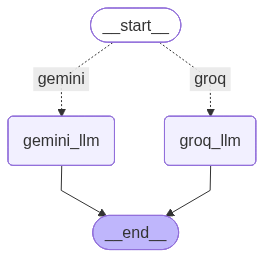

In [394]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [395]:
def process(prompt=""):
    prompt = HumanMessage(content=prompt)

    inputs = {
        'messages':[prompt]
    }

    # for output in app.stream(inputs):
    #     for key,value in output.items():
    #         logger.info(f"Output from node '{key}':")
    #         logger.info(value)

    results = app.invoke(inputs)

    for message in results["messages"]:
     logger.info(f'{message.type} : {message.content}')
     print(f'{message.type} : {message.content}')

In [396]:
# router_llm({"messages":[HumanMessage(content="Hi ! What is 2 + 2 ? ")]})
process("Hi ! What is 2 + 2 ? ")

Routing to Groq
human : Hi ! What is 2 + 2 ? 
ai : 4


In [397]:
process("Why is sunlight visible even after sunset?")

Routing to Gemini
human : Why is sunlight visible even after sunset?
ai : Even after the sun has dipped below the horizon, its light remains visible for some time due to a fascinating interplay of atmospheric phenomena: **atmospheric scattering**, **refraction**, and the **geometry of sunlight hitting the upper atmosphere**.

Here's a breakdown:

1.  **Atmospheric Scattering (Rayleigh Scattering):**
    Sunlight is composed of all colors of the rainbow. As this light enters Earth's atmosphere, it interacts with gas molecules and tiny particles. Shorter wavelengths of light (like blue and violet) are scattered much more efficiently than longer wavelengths (like red and orange).
    *   **During the day:** Blue light is scattered across the sky, making it appear blue.
    *   **At sunset/after sunset:** The sun's rays travel through a much thicker and longer path of atmosphere to reach your eyes. By the time this light reaches you, most of the blue and green light has been scattered away